## Modeling — Binary At-Risk (SMOTE + Bayesian Optimization, F1 At-Risk)

Gộp **Fail** và **Withdrawn** thành một lớp duy nhất: **At-risk**. Lớp còn lại là **Pass**.

Mỗi `prediction_point` train một model riêng:
1. **SMOTE** — oversample At-risk, tỷ lệ tăng `(1 + x) * N_current` với `x ∈ [0.1, 0.9]`
2. **Bayesian Optimization** — tìm đồng thời: hyperparameter mô hình + SMOTE ratio + class weight cho At-risk
3. **Metric**: F1-score của At-risk (đổi từ recall thuần vì recall-only khiến model dự đoán toàn bộ về At-risk)
4. **Evaluate** — test với `predict()` thông thường, không threshold tuning

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED, SNAPSHOTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score,
)

In [2]:
data_dir = Path('../data/processed')

X_train    = pd.read_parquet(data_dir / 'X_train.parquet')
X_test     = pd.read_parquet(data_dir / 'X_test.parquet')
y_train    = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test     = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

# Gộp Fail (0) và Withdrawn (2) thành At-risk (1); Pass (1) -> 0
LABEL_MAP = {0: 1, 1: 0, 2: 1}
y_train = y_train.map(LABEL_MAP)
y_test  = y_test.map(LABEL_MAP)

TARGET_NAMES = ['Pass', 'At-risk']

print('X_train:', X_train.shape)
print('Features:', list(X_train.columns))
print('Snapshots:', sorted(train_meta['prediction_point'].unique()))
print('Phân phối nhãn (train):', y_train.value_counts().to_dict())

X_train: (142384, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Snapshots: [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(150), np.int64(180), np.int64(210), np.int64(240)]
Phân phối nhãn (train): {0: 88536, 1: 53848}


### Helper functions

In [3]:
def get_snapshot_data(T):
    mask_tr = train_meta['prediction_point'].values == T
    mask_te = test_meta['prediction_point'].values == T
    return (
        X_train[mask_tr].reset_index(drop=True),
        X_test[mask_te].reset_index(drop=True),
        y_train[mask_tr].reset_index(drop=True),
        y_test[mask_te].reset_index(drop=True),
    )


def safe_smote(X, y, ratio_at_risk=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio in [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_at_risk = (y_s == 1).sum()
    n_pass    = (y_s == 0).sum()
    target = {1: int((1 + ratio_at_risk) * n_at_risk)}
    k = max(1, min(5, n_at_risk - 1, n_pass - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — tất cả prediction_point

**Ước tính runtime:** ~1-2 giờ (8 mốc x 30 trials x 3 folds + 1 lần retrain mỗi mốc)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (`C` — hệ số điều chuẩn của Logistic Regression)
- SMOTE ratio cho At-risk (`smote_ratio_at_risk` trong [0.1, 0.9])
- Class weight cho At-risk (`w_at_risk` trong [1, 8])

Vì Logistic Regression nhạy với thang đo của đặc trưng, dữ liệu được chuẩn hoá
bằng `StandardScaler` (fit trên train-fold, áp dụng cho val-fold, tránh rò rỉ
dữ liệu) trước khi SMOTE và huấn luyện.

**Lưu ý:** ban đầu tối ưu thuần recall At-risk khiến model dự đoán toàn bộ là At-risk (recall=1 nhưng precision rất thấp). Đã đổi metric tối ưu sang **F1-score At-risk** để cân bằng precision/recall.


############################################################
  PREDICTION POINT = 30 days
############################################################
Train: 19,988 | Test: 5,043


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.6723
SMOTE  -> At-risk: +0.56x
Weight -> At-risk: 1.24



  T=30
              precision    recall  f1-score   support

        Pass      0.772     0.511     0.615      2804
     At-risk      0.570     0.812     0.669      2239

    accuracy                          0.644      5043
   macro avg      0.671     0.661     0.642      5043
weighted avg      0.682     0.644     0.639      5043



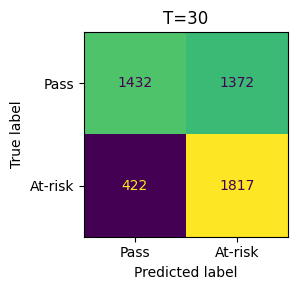


############################################################
  PREDICTION POINT = 60 days
############################################################
Train: 19,123 | Test: 4,835


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7065
SMOTE  -> At-risk: +0.63x
Weight -> At-risk: 1.01



  T=60
              precision    recall  f1-score   support

        Pass      0.789     0.745     0.767      2804
     At-risk      0.673     0.726     0.699      2031

    accuracy                          0.737      4835
   macro avg      0.731     0.735     0.733      4835
weighted avg      0.741     0.737     0.738      4835



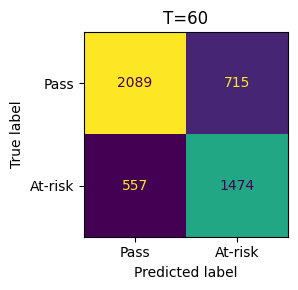


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7160
SMOTE  -> At-risk: +0.57x
Weight -> At-risk: 1.33



  T=90
              precision    recall  f1-score   support

        Pass      0.832     0.710     0.766      2804
     At-risk      0.644     0.786     0.708      1876

    accuracy                          0.740      4680
   macro avg      0.738     0.748     0.737      4680
weighted avg      0.757     0.740     0.743      4680



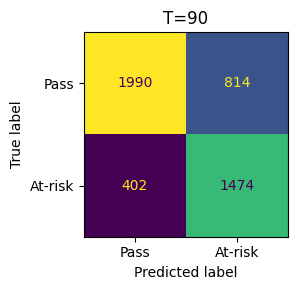


############################################################
  PREDICTION POINT = 120 days
############################################################


Train: 17,917 | Test: 4,518


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7485
SMOTE  -> At-risk: +0.53x
Weight -> At-risk: 1.13



  T=120
              precision    recall  f1-score   support

        Pass      0.844     0.811     0.827      2804
     At-risk      0.710     0.756     0.732      1714

    accuracy                          0.790      4518
   macro avg      0.777     0.783     0.780      4518
weighted avg      0.793     0.790     0.791      4518



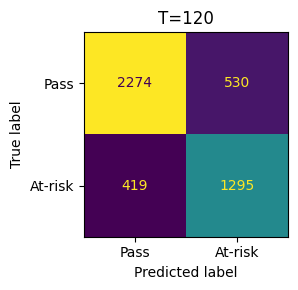


############################################################
  PREDICTION POINT = 150 days
############################################################


Train: 17,386 | Test: 4,363


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7762
SMOTE  -> At-risk: +0.43x
Weight -> At-risk: 1.11



  T=150
              precision    recall  f1-score   support

        Pass      0.865     0.864     0.865      2804
     At-risk      0.756     0.758     0.757      1559

    accuracy                          0.826      4363
   macro avg      0.811     0.811     0.811      4363
weighted avg      0.826     0.826     0.826      4363



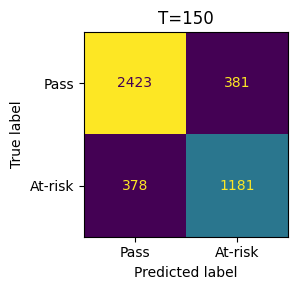


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7923
SMOTE  -> At-risk: +0.88x
Weight -> At-risk: 1.01



  T=180
              precision    recall  f1-score   support

        Pass      0.895     0.870     0.882      2804
     At-risk      0.755     0.798     0.776      1411

    accuracy                          0.846      4215
   macro avg      0.825     0.834     0.829      4215
weighted avg      0.848     0.846     0.847      4215



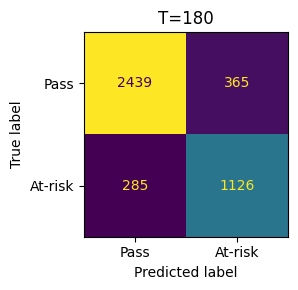


############################################################
  PREDICTION POINT = 210 days
############################################################


Train: 16,486 | Test: 4,162


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8042
SMOTE  -> At-risk: +0.51x
Weight -> At-risk: 1.03



  T=210
              precision    recall  f1-score   support

        Pass      0.896     0.903     0.899      2804
     At-risk      0.796     0.784     0.790      1358

    accuracy                          0.864      4162
   macro avg      0.846     0.843     0.845      4162
weighted avg      0.864     0.864     0.864      4162



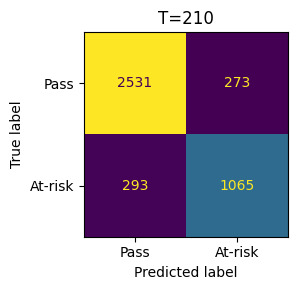


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8174
SMOTE  -> At-risk: +0.51x
Weight -> At-risk: 1.03



  T=240
              precision    recall  f1-score   support

        Pass      0.905     0.918     0.911      2804
     At-risk      0.815     0.790     0.802      1290

    accuracy                          0.877      4094
   macro avg      0.860     0.854     0.857      4094
weighted avg      0.877     0.877     0.877      4094



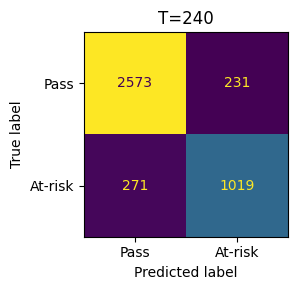


--- Tổng hợp ---


,prediction_point,accuracy,recall_pass,recall_at_risk,precision_pass,precision_at_risk,f1_at_risk
0,30,0.6443,0.5107,0.8115,0.7724,0.5698,0.6695
1,60,0.7369,0.7450,0.7258,0.7895,0.6734,0.6986
2,90,0.7402,0.7097,0.7857,0.8319,0.6442,0.7080
3,120,0.7900,0.8110,0.7555,0.8444,0.7096,0.7318
4,150,0.8260,0.8641,0.7575,0.8650,0.7561,0.7568
5,180,0.8458,0.8698,0.7980,0.8954,0.7552,0.7760
6,210,0.8640,0.9026,0.7842,0.8962,0.7960,0.7901
7,240,0.8774,0.9176,0.7899,0.9047,0.8152,0.8024


In [4]:
models  = {}
results = []

for T in SNAPSHOTS:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        }
        r_at_risk = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w_at_risk = trial.suggest_float('w_at_risk', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            scaler = StandardScaler().fit(Xf_tr)
            Xf_tr  = scaler.transform(Xf_tr)
            Xf_val = scaler.transform(Xf_val)

            Xf_sm, yf_sm = safe_smote(Xf_tr, yf_tr, r_at_risk)
            m = LogisticRegression(
                **params,
                max_iter=1000,
                class_weight={0: 1.0, 1: w_at_risk},
                random_state=RANDOM_SEED,
            )
            m.fit(Xf_sm, yf_sm)

            score = f1_score(yf_val, m.predict(Xf_val), pos_label=1, zero_division=0)
            fold_scores.append(score)
        return np.mean(fold_scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best = study.best_params
    print(f'Best F1 At-risk CV: {study.best_value:.4f}')
    print(f'SMOTE  -> At-risk: +{best["smote_ratio_at_risk"]:.2f}x')
    print(f'Weight -> At-risk: {best["w_at_risk"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    scaler_final = StandardScaler().fit(X_tr)
    X_tr_scaled = scaler_final.transform(X_tr)
    X_te_scaled = scaler_final.transform(X_te)

    X_sm, y_sm = safe_smote(X_tr_scaled, y_tr, ratio_at_risk=best['smote_ratio_at_risk'])
    model_final = LogisticRegression(
        C=best['C'],
        max_iter=1000,
        class_weight={0: 1.0, 1: best['w_at_risk']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te_scaled))
    evaluate_full(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    results.append({
        'prediction_point':   T,
        'accuracy':           round(accuracy_score(y_te, y_pred), 4),
        'recall_pass':        round(recalls[0], 4),
        'recall_at_risk':     round(recalls[1], 4),
        'precision_pass':     round(precisions[0], 4),
        'precision_at_risk':  round(precisions[1], 4),
        'f1_at_risk':         round(f1_score(y_te, y_pred, pos_label=1, zero_division=0), 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df